# **Data prepropcessing**

The initial step in preprocessing focuses on selecting the most relevant data attributes (columns) and records (rows) to align with the overall analysis objectives. This selection is guided by the goals of data mining, specifically, identifying key lifestyle factors that influence academic performance, prioritizing attributes that are both analytically meaningful and technically feasible.

However, since the main aim is to build a classification model that fulfills both business and data mining objectives, this initial step must be extended by creating a binary classification label based on exam scores. For the purpose of this analysis, it is assumed that `exam_score` reflects an aggregate or average score across all academic modules, thereby serving as a suitable target variable.

## **Generate a binary classification label: AtRisk vs. NotAtRisk**

To establish a classification target, it was assumed that `exam_score` represents an aggregate or average across all academic modules. Based on this, a new categorical variable, `grade`, was created by mapping numerical scores to standard letter grades from A to F, excluding subcategories such as A− or B+. This allowed for broader performance groupings. A binary label, `risk_status`, was then derived to indicate whether a student is **AtRisk** (grade D or F) or **NotAtRisk** (grade above D), thereby framing the problem as a binary classification task aimed at supporting early academic intervention strategies.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import plotly.express as px
%matplotlib inline

In [2]:
sd = pd.read_csv("data/student_habits_performance.csv")
sd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

This code defines a function, `convert_to_letter_grade`, that maps numerical exam scores to standard letter grades based on predefined thresholds. It then applies this function to the `exam_score` column of the DataFrame `sd`, creating a new column called `grade` with the corresponding letter grades.

In [3]:
def convert_to_letter_grade(score):
    if score >= 80:
        return 'A'
    elif score >= 70:
        return 'B'
    elif score >= 60:
        return 'C'
    elif score >= 50:
        return 'D'
    else:
        return 'F'

# Create 'grade' attribute
sd['grade'] = sd['exam_score'].apply(convert_to_letter_grade)
sd.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,grade
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2,D
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0,A
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3,F
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8,F
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4,C


In [4]:
print(sd['grade'].unique())
grade_counts = sd['grade'].value_counts().sort_index()
print(grade_counts)

['D' 'A' 'F' 'C' 'B']
grade
A    277
B    234
C    209
D    149
F    131
Name: count, dtype: int64


The code below creates a new column called `risk_status` in the `sd` DataFrame. It checks each student's `grade` and assigns **'AtRisk'** if the grade is **D** or **F**, and **'NotAtRisk'** for all other grades.

In [5]:
# Create risk_status attribute
sd['risk_status'] = sd['grade'].apply(lambda x: 'AtRisk' if x in ['D', 'F'] else 'NotAtRisk')
sd.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,grade,risk_status
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2,D,AtRisk
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0,A,NotAtRisk
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3,F,AtRisk
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8,F,AtRisk
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4,C,NotAtRisk


In [6]:
risk_status_counts = sd['risk_status'].value_counts().sort_index()
print(risk_status_counts)

risk_status
AtRisk       280
NotAtRisk    720
Name: count, dtype: int64


This output shows a class imbalance in the `risk_status` variable. There are **720** students labeled as **NotAtRisk** and only **280** as **AtRisk**. This imbalance—approximately 72% vs. 28%—should be taken into account when building the classification model, as it may bias the model toward predicting the majority class. Techniques such as resampling, class weighting, and using appropriate evaluation metrics (like F1-score or AUC) can help address this issue.

## **Outlier initial detection and analysis**

The outliers identified in the dataset, representing both extreme low and high-performing students, offer valuable insights into the student population and should not be removed, as they reflect real-world extremes that can enhance model performance. The **IsolationForest** algorithm with **contamination=0.025** and **random\_state=42** effectively identified subtle anomalies without flagging valid data, striking a balance between sensitivity and accuracy. To mitigate the impact of these outliers on the model, the **DecisionTreeDescritizer* will be used later to handle them more effectively, ensuring a robust model while preserving the integrity of the data.

In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# Select numeric features for outlier detection
features = ['study_hours_per_day', 'exam_score', 'sleep_hours', 'social_media_hours', 
            'mental_health_rating', 'attendance_percentage', 'exercise_frequency']

# Use 'sd' as the dataset name
df = sd[features].dropna()
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Apply Isolation Forest
iso = IsolationForest(contamination=0.025, random_state=42)
outlier_pred = iso.fit_predict(df_scaled)  # -1 = outlier, 1 = inlier

# Reduce dimensions for visualization using PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Create a DataFrame for plotting and row extraction
outlier_df = sd.loc[df.index].copy()
outlier_df['PCA1'] = df_pca[:, 0]
outlier_df['PCA2'] = df_pca[:, 1]
outlier_df['outlier_flag'] = outlier_pred

# Show outliers only (text output)
outliers_only = outlier_df[outlier_df['outlier_flag'] == -1]
print(f"Number of outliers detected: {len(outliers_only)}")
print(outliers_only[['exam_score', 'study_hours_per_day', 'mental_health_rating', 'social_media_hours']].to_string())

Number of outliers detected: 25
     exam_score  study_hours_per_day  mental_health_rating  social_media_hours
3          26.8                  1.0                     1                 3.9
23         43.7                  1.1                     1                 4.1
92         43.9                  0.5                     3                 0.8
195        26.7                  0.0                     5                 2.8
322        96.1                  6.1                    10                 4.9
411        58.2                  1.6                    10                 0.8
414        78.7                  4.2                     5                 5.6
422        29.5                  2.0                     2                 2.4
431        29.9                  0.0                     2                 2.0
447        93.6                  5.9                     1                 0.0
590        42.0                  0.0                     7                 4.6
630        50.3     

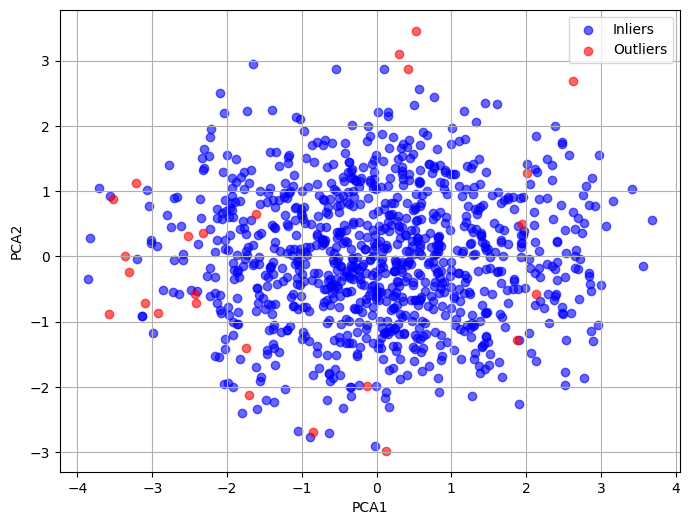

In [13]:
import matplotlib.pyplot as plt

# Create the figure
plt.figure(figsize=(8, 6))

# Plot inliers (label = 1, blue)
inliers = outlier_df[outlier_df['outlier_flag'] == 1]
plt.scatter(inliers['PCA1'], inliers['PCA2'], 
            c='blue', alpha=0.6, label='Inliers')

# Plot outliers (label = -1, red)
outliers = outlier_df[outlier_df['outlier_flag'] == -1]
plt.scatter(outliers['PCA1'], outliers['PCA2'], 
            c='red', alpha=0.6, label='Outliers')

# Axis labels and grid
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.grid(True)
plt.legend()

# Save the figure
plt.savefig('img/outlier_detection_plot.png', format='png')

# Show the plot
plt.show()


## **Baseline models**

Before starting the preprocessing phase, it is useful to build simple **baseline models** to set a reference point for performance. These models help evaluate whether future improvements, such as feature selection or data transformation, actually lead to better results. A baseline model is typically created using the raw or minimally processed data and serves as a benchmark for comparison throughout the analysis.

In [14]:
# Separate the target variable (risk_status) from the feature set
sd_y = sd['risk_status']
sd_X = sd[sd.columns.difference(['risk_status'])]

In [15]:
from sklearn.preprocessing import OrdinalEncoder

# Keep sd_X as originally defined
# Make a copy for the following trainings 
sd_XX = sd_X.copy()
# Retrieve the regular numeric columns names
num_cols = list(sd_XX.select_dtypes(include=['int64','float64']).columns)
# Retrive the regular object columns names
cat_cols = list(sd_XX.select_dtypes(include=['object']).columns)
# Replace missing/nan values with 0 for numerical columns
sd_XX[num_cols] = sd_XX[num_cols].apply(lambda col: col.fillna(0, axis=0))
# Replace missing/nan values with '?' for object columns
sd_XX[cat_cols] = sd_XX[cat_cols].apply(lambda col: col.fillna('?', axis=0).astype(str))
# Encode the object columns using an OrdinalEncoder instance
ordinal_encoder = OrdinalEncoder()

sd_XX[cat_cols] = ordinal_encoder.fit_transform(sd_XX[cat_cols])
sd_XX.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1000 non-null   int64  
 1   attendance_percentage          1000 non-null   float64
 2   diet_quality                   1000 non-null   float64
 3   exam_score                     1000 non-null   float64
 4   exercise_frequency             1000 non-null   int64  
 5   extracurricular_participation  1000 non-null   float64
 6   gender                         1000 non-null   float64
 7   grade                          1000 non-null   float64
 8   internet_quality               1000 non-null   float64
 9   mental_health_rating           1000 non-null   int64  
 10  netflix_hours                  1000 non-null   float64
 11  parental_education_level       1000 non-null   float64
 12  part_time_job                  1000 non-null   fl

In [16]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
import adsa_utils as ad

# Create an instance of the DT classifier leaving
# All hyperparameters to default values except random_state
clf = DecisionTreeClassifier(random_state=43)
# Crossvalidate on the encoded train portion using the custom function
ad.cross_validation_avg_scores(sd_XX, sd_y, clf)

Mean Accuracy is 100.00 +/- 0.00
Mean Precision is 100.00 +/- 0.00
Mean Recall is 100.00 +/- 0.00
Mean F-score is 100.00 +/- 0.00


The perfect performance observed should be questioned, prompting a deeper exploration of the dataset. It is important to review the feature definitions or investigate the tree model to better understand the results.

In [17]:
# Remove the proxy columns to avoid data leakage
sd_XX = sd_XX.drop(columns=['exam_score', 'grade'])
sd_XX.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1000 non-null   int64  
 1   attendance_percentage          1000 non-null   float64
 2   diet_quality                   1000 non-null   float64
 3   exercise_frequency             1000 non-null   int64  
 4   extracurricular_participation  1000 non-null   float64
 5   gender                         1000 non-null   float64
 6   internet_quality               1000 non-null   float64
 7   mental_health_rating           1000 non-null   int64  
 8   netflix_hours                  1000 non-null   float64
 9   parental_education_level       1000 non-null   float64
 10  part_time_job                  1000 non-null   float64
 11  sleep_hours                    1000 non-null   float64
 12  social_media_hours             1000 non-null   fl

In [18]:
ad.cross_validation_avg_scores(sd_XX, sd_y, clf)

Mean Accuracy is 84.10 +/- 1.32
Mean Precision is 80.32 +/- 1.65
Mean Recall is 80.12 +/- 1.69
Mean F-score is 80.22 +/- 1.66


## **Data selection**


The first step in preparing the data is choosing the most important columns and rows to match the goals of the analysis. These choices were based on data understanding phase. The selected features were those that had a strong link to general exam scores. The attribute **`student_id`** is a unique identifier, it should be dropped as it holds no analytical value for modeling or interpretation.

In [19]:
sd_XX.drop(columns='student_id', inplace=True)
ad.cross_validation_avg_scores(sd_XX, sd_y, clf)

Mean Accuracy is 85.00 +/- 2.17
Mean Precision is 81.45 +/- 2.71
Mean Recall is 81.51 +/- 2.33
Mean F-score is 81.45 +/- 2.50


The right way to remove unnecessary attributes is by first reviewing the summary statistics and visual plots for each one. Decisions should be based on things like value ranges, percentiles, and overall distribution. Start by generating summary statistics for all attributes.

In [20]:
sd.describe(include='all')

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,grade,risk_status
count,1000,1000.0000,1000,1000.00000,1000.000000,1000.000000,1000,1000.000000,1000.000000,1000,1000.000000,909,1000,1000.000000,1000,1000.000000,1000,1000
unique,1000,NaN,3,NaN,NaN,NaN,2,NaN,NaN,3,NaN,3,3,NaN,2,NaN,5,2
top,S1000,NaN,Female,NaN,NaN,NaN,No,NaN,NaN,Fair,NaN,High School,Good,NaN,No,NaN,A,NotAtRisk
freq,1,NaN,481,NaN,NaN,NaN,785,NaN,NaN,437,NaN,392,447,NaN,682,NaN,277,720
mean,NaN,20.4980,NaN,3.55010,2.505500,1.819700,NaN,84.131700,6.470100,NaN,3.042000,NaN,NaN,5.438000,NaN,69.601500,NaN,NaN
std,NaN,2.3081,NaN,1.46889,1.172422,1.075118,NaN,9.399246,1.226377,NaN,2.025423,NaN,NaN,2.847501,NaN,16.888564,NaN,NaN
min,NaN,17.0000,NaN,0.00000,0.000000,0.000000,NaN,56.000000,3.200000,NaN,0.000000,NaN,NaN,1.000000,NaN,18.400000,NaN,NaN
25%,NaN,18.7500,NaN,2.60000,1.700000,1.000000,NaN,78.000000,5.600000,NaN,1.000000,NaN,NaN,3.000000,NaN,58.475000,NaN,NaN
50%,NaN,20.0000,NaN,3.50000,2.500000,1.800000,NaN,84.400000,6.500000,NaN,3.000000,NaN,NaN,5.000000,NaN,70.500000,NaN,NaN
75%,NaN,23.0000,NaN,4.50000,3.300000,2.525000,NaN,91.025000,7.300000,NaN,5.000000,NaN,NaN,8.000000,NaN,81.325000,NaN,NaN


Based on the summary statistics, all attributes, except for the unique identifier (ID) already removed, show meaningful variability, which suggests they can contribute valuable information to the analysis. None of the features have constant or near-constant values, and most display a reasonable spread across their ranges, as seen in their standard deviations and percentiles. This variation is important for identifying potential patterns or relationships with academic performance. Therefore, **it is justified to retain all attributes for further analysis, except the ID column, which serves only as a unique identifier and carries no analytical value**.

In [21]:
from feature_engine.selection import SmartCorrelatedSelection

# Configure the SmartCorrelationSelection feature engine
scs_selector = SmartCorrelatedSelection(
    variables=None,
    method="pearson",
    threshold=0.95,
    selection_method="variance",
    estimator=None,
)

sd_XX = scs_selector.fit_transform(sd_XX)

print(f"Highly correlated feature sets (potential multicollinearity): {scs_selector.correlated_feature_sets_}")
print(f"Features recommended for removal due to high correlation: {scs_selector.features_to_drop_}")

Highly correlated feature sets (potential multicollinearity): []
Features recommended for removal due to high correlation: []


The results show that there are no highly correlated feature sets and no features recommended for removal based on the specified correlation threshold. This confirms that all features (excluding the ID) are sufficiently distinct and should be retained for analysis.

## **Data cleaning**

### **Dealing with missing values**

The attribute `parental_education_level` is the only feature with missing values. Based on our understanding of the data and the moderate importance of this attribute as a socioeconomic indicator, a straightforward and effective approach is to impute the missing values using the **mode** (the most frequent category). This method is simple, maintains the original class distribution, and avoids introducing artificial variability—making it well-suited for a **categorical** variable with a clear ordinal structure.

In [22]:
sd_XX = sd_X.copy()
# Remove id attribute
sd_XX.drop(columns='student_id', inplace=True)
# Check missing values
print(sd_XX.isnull().sum())

age                               0
attendance_percentage             0
diet_quality                      0
exam_score                        0
exercise_frequency                0
extracurricular_participation     0
gender                            0
grade                             0
internet_quality                  0
mental_health_rating              0
netflix_hours                     0
parental_education_level         91
part_time_job                     0
sleep_hours                       0
social_media_hours                0
study_hours_per_day               0
dtype: int64


In [23]:
# Impute missing values in 'parental_education_level' with the mode
sd_XX['parental_education_level'] = sd_XX['parental_education_level'].fillna(sd_XX['parental_education_level'].mode()[0])
# Check missing values
print(sd_XX.isnull().sum())

age                              0
attendance_percentage            0
diet_quality                     0
exam_score                       0
exercise_frequency               0
extracurricular_participation    0
gender                           0
grade                            0
internet_quality                 0
mental_health_rating             0
netflix_hours                    0
parental_education_level         0
part_time_job                    0
sleep_hours                      0
social_media_hours               0
study_hours_per_day              0
dtype: int64


In [24]:
# Remove the proxy columns to avoid data leakage
sd_XX = sd_XX.drop(columns=['exam_score', 'grade'])

In [25]:
cat_cols = list(sd_XX.select_dtypes(include=['object']).columns)

ordinal_encoder = OrdinalEncoder()
sd_XX[cat_cols] = ordinal_encoder.fit_transform(sd_XX[cat_cols])

clf = DecisionTreeClassifier(random_state=43)
ad.cross_validation_avg_scores(sd_XX, sd_y, clf)

Mean Accuracy is 85.10 +/- 2.80
Mean Precision is 81.65 +/- 3.57
Mean Recall is 81.47 +/- 2.85
Mean F-score is 81.54 +/- 3.21


In [26]:
from sklearn.impute import KNNImputer

sd_XX = sd_X.copy()
sd_XX.drop(columns='student_id', inplace=True)
sd_XX = sd_XX.drop(columns=['exam_score', 'grade'])

cat_cols = list(sd_XX.select_dtypes(include=['object']).columns)

ordinal_encoder = OrdinalEncoder()
sd_XX[cat_cols] = ordinal_encoder.fit_transform(sd_XX[cat_cols])

# Fill missing value in using KNN imputer from scikit-learn
imputer = KNNImputer() # default n_neighbors=5, n_neighbors
# n_neighbors 3 and 7 where tested an the performace declined compared to the previous mode imputation
sd_XX[list(sd_XX.columns)] = imputer.fit_transform(sd_XX[list(sd_XX.columns)])

clf = DecisionTreeClassifier(random_state=43)
ad.cross_validation_avg_scores(sd_XX, sd_y, clf)

Mean Accuracy is 84.70 +/- 2.64
Mean Precision is 81.16 +/- 3.30
Mean Recall is 80.86 +/- 2.85
Mean F-score is 80.99 +/- 3.06


Since mode imputation by class yielded the same results as overall mode imputation for `parental_education_level`, the simpler approach was chosen. The overall mode was used, as it is straightforward, easy to implement, and equally effective in this context. The **KNNImputer** alternative imputation method with different values of `n_neighbors` (3, 5, and 7) were tested, but they resulted in a decline in model performance. This further supported the decision to use mode imputation.

In [27]:
sd_XX = sd_X.copy()

sd_XX.drop(columns='student_id', inplace=True)
sd_XX = sd_XX.drop(columns=['exam_score', 'grade'])

# Impute missing values in 'parental_education_level' with the mode
sd_XX['parental_education_level'] = sd_XX['parental_education_level'].fillna(sd_XX['parental_education_level'].mode()[0])
cat_cols = list(sd_XX.select_dtypes(include=['object']).columns)

ordinal_encoder = OrdinalEncoder()
sd_XX[cat_cols] = ordinal_encoder.fit_transform(sd_XX[cat_cols])

clf = DecisionTreeClassifier(random_state=43, class_weight='balanced')
ad.cross_validation_avg_scores(sd_XX, sd_y, clf)

Mean Accuracy is 85.80 +/- 1.72
Mean Precision is 82.91 +/- 2.49
Mean Recall is 81.41 +/- 1.69
Mean F-score is 82.04 +/- 1.94


Before any data transformation or reweighting, the target variable `risk_status` showed a clear imbalance: 72% *NotAtRisk* vs. 28% *AtRisk*. This imbalance can bias models toward the majority class, often inflating accuracy while failing to properly identify *AtRisk* students. By applying `class_weight='balanced'` and using mode imputation for the missing values, model performance **significantly improved** across all key metrics—accuracy rose from **84.70% to 85.80%**, and F1-score from **80.99% to 82.04%**. These improvements highlight the importance of addressing class imbalance and choosing the right imputation strategy to ensure fairer and more effective classification.

### **Dealing with noise and outliers**


To handle noise and outliers, the **DecisionTreeDiscretiser** was used, which applies decision tree-based discretization to continuous variables. This method divides the data into intervals based on the inherent structure of the data, effectively capturing the relationships between features and the target variable. Unlike unsupervised discretizers, which simply group values into bins without considering the target variable, the **DecisionTreeDiscretiser** optimizes splits based on class labels. This leads to more meaningful and robust intervals, improving model performance by reducing the impact of noise and outliers while preserving important patterns. The results showed better performance compared to traditional unsupervised discretization, particularly in handling complex relationships within the data.

Mean Accuracy is 85.00 +/- 1.63
Mean Precision is 81.78 +/- 1.80
Mean Recall is 81.27 +/- 2.65
Mean F-score is 81.47 +/- 2.22
              precision    recall  f1-score   support

      AtRisk       0.72      0.76      0.74        51
   NotAtRisk       0.92      0.90      0.91       149

    accuracy                           0.86       200
   macro avg       0.82      0.83      0.83       200
weighted avg       0.87      0.86      0.87       200



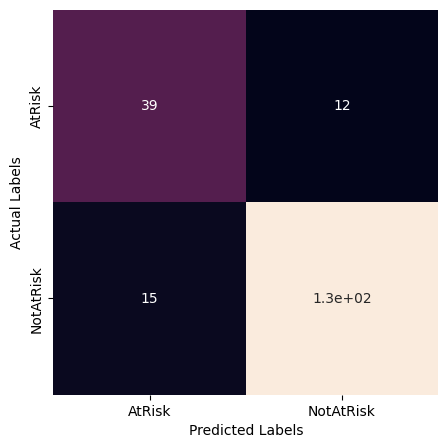

In [28]:
from sklearn.model_selection import train_test_split, cross_validate
from feature_engine.discretisation import DecisionTreeDiscretiser
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
import adsa_utils as ad

sd_XX = sd_X.copy()
sd_XX.drop(columns=['student_id', 'exam_score', 'grade'], inplace=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    sd_XX, sd_y, test_size=0.2, random_state=43
)

# Supervised binning of numerical features
dt_binner = DecisionTreeDiscretiser(
    bin_output='boundaries',
    cv=5,
    precision=2,
    scoring='accuracy',
    regression=False,
    random_state=43,
    param_grid={'max_depth': [3, 5], 'ccp_alpha': [0.0, 0.01, 0.1]}
)

# Fit + transform on train
X_train_binned = dt_binner.fit_transform(X_train, y_train)
X_test_binned  = dt_binner.transform(X_test)

X_train = pd.DataFrame(X_train_binned)
X_test = pd.DataFrame(X_test_binned)
y_train = pd.Series(y_train)

# Build a pipeline for the (now binned) data:
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Create a preprocessing pipeline 
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

# Fit the encoder on the binned training set
X_train = pd.DataFrame(cat_pipeline.fit_transform(X_train[cat_cols]), columns=cat_cols)
X_test  = pd.DataFrame(cat_pipeline.transform(X_test[cat_cols]), columns=cat_cols)

clf = DecisionTreeClassifier(random_state=43, class_weight='balanced')

# Train the model
ad.cross_validation_avg_scores(X_train, y_train, clf, cv_=5, print_dict=False)

# Evaluation
y_pred = clf.predict(X_test)
print(ad.classification_report(y_test, y_pred))
ad.plot_confusion_matrix(y_test, y_pred)

## **Construct data**

### **Binning numerical attributes**

Binning is a preprocessing technique used to convert continuous numerical variables into categorical intervals, which can simplify models and enhance performance, especially for tree-based algorithms. Two common approaches are unsupervised binning, which relies solely on the distribution of the feature, and supervised binning, which also considers the target variable. The following comparison illustrates the impact of each approach on model performance.

Mean Accuracy is 82.00 +/- 1.83
Mean Precision is 78.28 +/- 2.39
Mean Recall is 77.56 +/- 2.63
Mean F-score is 77.74 +/- 2.22
Best parameters found: {'preprocessor__num__discretizer__n_bins': 5, 'preprocessor__num__discretizer__strategy': 'quantile'}
              precision    recall  f1-score   support

      AtRisk       0.61      0.67      0.64        51
   NotAtRisk       0.88      0.85      0.87       149

    accuracy                           0.81       200
   macro avg       0.74      0.76      0.75       200
weighted avg       0.81      0.81      0.81       200



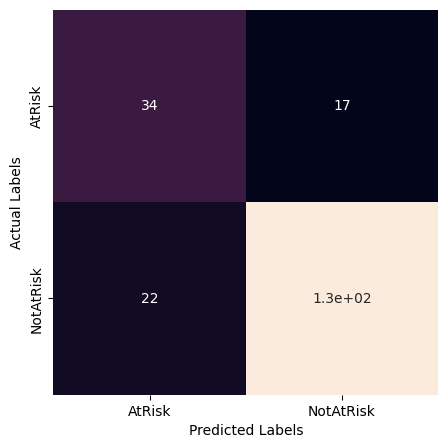

In [29]:
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import GridSearchCV

sd_XX = sd_X.copy()
sd_XX.drop(columns=['student_id', 'exam_score', 'grade'], inplace=True)

# Identify categorical and numerical columns
cat_cols = sd_XX.select_dtypes(include=['object']).columns.tolist()
num_cols = sd_XX.select_dtypes(exclude=['object']).columns.tolist()

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    sd_XX, sd_y, test_size=0.2, random_state=43
)

# Pipeline for categorical columns: mode imputation + ordinal encoding
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

# Pipeline for numerical columns: discretization with unsupervized KBinsDiscretizer
num_pipeline = Pipeline(steps=[
    ('discretizer', KBinsDiscretizer(encode='ordinal', strategy='uniform', subsample=None))
])

cat_indices = [sd_XX.columns.get_loc(col) for col in cat_cols]
num_indices = [sd_XX.columns.get_loc(col) for col in num_cols]

# Combine categorical and numerical preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('cat', cat_pipeline, cat_indices),
    ('num', num_pipeline, num_indices)
])

# Full pipeline with classifier
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(class_weight='balanced', random_state=43))
])

# Set up GridSearchCV for KBinsDiscretizer parameters
param_grid = {
    'preprocessor__num__discretizer__n_bins': [3, 5],
    'preprocessor__num__discretizer__strategy': ['uniform', 'quantile', 'kmeans']
}

# Perform GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Cross-validation using grid_search.best_estimator_
ad.cross_validation_avg_scores(X_train, y_train, grid_search.best_estimator_, cv_=5, print_dict=False)

# Print best parameters and performance
print(f'Best parameters found: {grid_search.best_params_}')

# Evaluation
y_pred = grid_search.best_estimator_.predict(X_test)
print(ad.classification_report(y_test, y_pred))
ad.plot_confusion_matrix(y_test, y_pred)

Mean Accuracy is 84.75 +/- 1.88
Mean Precision is 81.81 +/- 2.96
Mean Recall is 80.93 +/- 2.77
Mean F-score is 81.14 +/- 2.33
              precision    recall  f1-score   support

      AtRisk       0.72      0.82      0.77        51
   NotAtRisk       0.94      0.89      0.91       149

    accuracy                           0.88       200
   macro avg       0.83      0.86      0.84       200
weighted avg       0.88      0.88      0.88       200



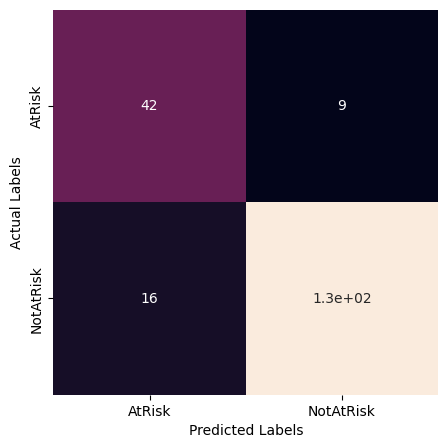

In [30]:
from feature_engine.discretisation import DecisionTreeDiscretiser

sd_XX = sd_X.copy()
sd_XX.drop(columns=['student_id', 'exam_score', 'grade'], inplace=True)

X_train, X_test, y_train, y_test = train_test_split(
    sd_XX, sd_y, test_size=0.2, random_state=43
)

# Supervised binning of numerical features
dt_binner = DecisionTreeDiscretiser(
    bin_output='boundaries',
    precision=2,
    scoring='accuracy',
    regression=False,
    random_state=43,
    param_grid={'max_depth': [3, 5], 'ccp_alpha': [0.0, 0.01, 0.1]}
)
# Fit + transform on train, transform on test
X_train_binned = dt_binner.fit_transform(X_train, y_train)
X_test_binned  = dt_binner.transform(X_test)

X_train = pd.DataFrame(X_train_binned)
X_test = pd.DataFrame(X_test_binned)
y_train = pd.Series(y_train)


# Build a pipeline for the (now binned) data:
# - impute any remaining categorical missings
# - ordinal‑encode every categorical column (including the original ones plus the new bin boundaries)
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Pipeline for the preprocessing
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

# Fit the encoder on the binned training set
X_train = pd.DataFrame(preprocessor.fit_transform(X_train[cat_cols]), columns=cat_cols)
X_test  = pd.DataFrame(preprocessor.transform(X_test[cat_cols]), columns=cat_cols)


# Train the model
clf = DecisionTreeClassifier(random_state=43, class_weight='balanced')
ad.cross_validation_avg_scores(X_train, y_train, clf, cv_=5, print_dict=False)

# Evaluation
y_pred = clf.predict(X_test)
print(ad.classification_report(y_test, y_pred))
ad.plot_confusion_matrix(y_test, y_pred)

The comparison between unsupervised and supervised discretization reveals that supervised binning provides a clear performance advantage. Using `KBinsDiscretizer` (unsupervised), the model achieved a mean accuracy of **82.00%** and an F1-score of **77.74%**, with best results obtained through quantile-based binning. In contrast, the `DecisionTreeDiscretiser` (supervised binning) significantly improved the model’s performance, reaching a mean accuracy of **85.00%** and an F1-score of **81.47%**. This improvement highlights the benefit of supervised binning, which takes the target variable into account during discretization, leading to more informative features and ultimately better classification results.

### **Aggregation**

Aggregation combines multiple related features into a single, more informative variable to simplify the data and enhance model performance. In this case, we explored two approaches—z-score summation and Principal Component Analysis (PCA)—to aggregate screen time and study-related attributes.

Mean Accuracy is 85.50 +/- 1.74
Mean Precision is 82.31 +/- 2.20
Mean Recall is 82.11 +/- 2.61
Mean F-score is 82.18 +/- 2.35
              precision    recall  f1-score   support

      AtRisk       0.73      0.71      0.72        51
   NotAtRisk       0.90      0.91      0.91       149

    accuracy                           0.86       200
   macro avg       0.82      0.81      0.81       200
weighted avg       0.86      0.86      0.86       200



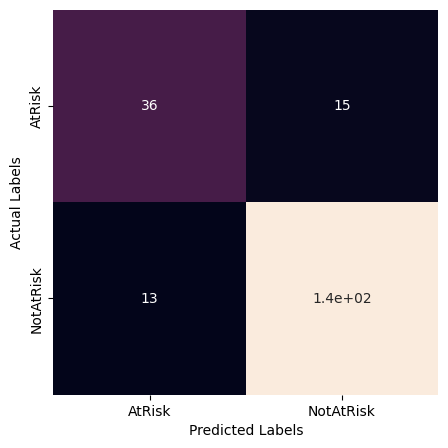

In [31]:
from sklearn.preprocessing import StandardScaler

sd_XX = sd_X.copy()

# Aggregate social media and Netflix hours into a total screen time, scale the values, and compute a scaled sum.
scaler = StandardScaler()
scaled = scaler.fit_transform(sd_XX[['social_media_hours', 'netflix_hours']])
sd_XX['z_screen_time'] = scaled[:, 0] + scaled[:, 1]
sd_XX[['social_media_hours_scaled', 'netflix_hours_scaled']] = scaled

# Drop unnecessary and aggregated columns (removing 'social_media_hours' and 'netflix_hours' provides better performance)
sd_XX.drop(columns=[
    'student_id', 'exam_score', 'grade', 'social_media_hours', 'netflix_hours'
], inplace=True)

X_train, X_test, y_train, y_test = train_test_split(
    sd_XX, sd_y, test_size=0.2, random_state=43
)

# Supervised binning of numerical features
dt_binner = DecisionTreeDiscretiser(
    bin_output='boundaries',
    cv=5,
    precision=2,
    scoring='accuracy',
    regression=False,
    random_state=43,
    param_grid={'max_depth': [3, 5], 'ccp_alpha': [0.0, 0.01, 0.1]}
)
# Fit + transform on train, transform on test
X_train_binned = dt_binner.fit_transform(X_train, y_train)
X_test_binned  = dt_binner.transform(X_test)

X_train = pd.DataFrame(X_train_binned)
X_test = pd.DataFrame(X_test_binned)
y_train = pd.Series(y_train)

# Build a pipeline for the (now binned) data:
# - impute any remaining categorical missings
# - ordinal‑encode every categorical column (including the original ones plus the new bin boundaries)
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Pipeline for the preprocessing
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

# Fit the encoder on the binned training set
X_train = pd.DataFrame(preprocessor.fit_transform(X_train[cat_cols]), columns=cat_cols)
X_test  = pd.DataFrame(preprocessor.transform(X_test[cat_cols]), columns=cat_cols)

# Train and evaluate the classifier
clf = DecisionTreeClassifier(random_state=43, class_weight='balanced')
ad.cross_validation_avg_scores(X_train, y_train, clf, cv_=5, print_dict=False)
y_pred = clf.predict(X_test)
print(ad.classification_report(y_test, y_pred))
ad.plot_confusion_matrix(y_test, y_pred)

Mean Accuracy is 84.88 +/- 1.08
Mean Precision is 81.84 +/- 1.42
Mean Recall is 80.64 +/- 1.74
Mean F-score is 81.15 +/- 1.44
              precision    recall  f1-score   support

      AtRisk       0.79      0.80      0.80        51
   NotAtRisk       0.93      0.93      0.93       149

    accuracy                           0.90       200
   macro avg       0.86      0.87      0.86       200
weighted avg       0.90      0.90      0.90       200



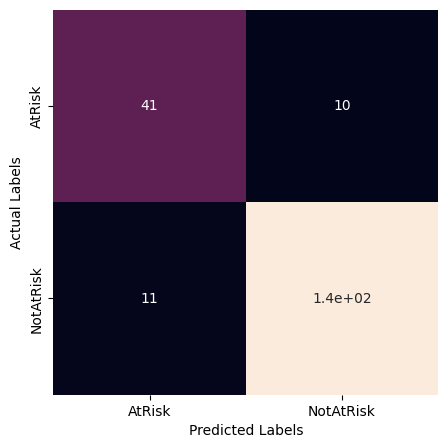

In [32]:
from sklearn.decomposition import PCA

sd_XX = sd_X.copy()

# Apply PCA on the original numerical data (social_media_hours, netflix_hours)
pca = PCA(n_components=1)
sd_XX['media_usage_hours_pca'] = pca.fit_transform(sd_XX[['social_media_hours', 'netflix_hours']])

# Drop unnecessary and redundant columns
sd_XX.drop(columns=[
    'student_id', 'exam_score', 'grade'
], inplace=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    sd_XX, sd_y, test_size=0.2, random_state=43
)

# Supervised binning of numerical features
dt_binner = DecisionTreeDiscretiser(
    bin_output='boundaries',
    cv=5,
    precision=2,
    scoring='accuracy',
    regression=False,
    random_state=43,
    param_grid={'max_depth': [3, 5], 'ccp_alpha': [0.0, 0.01, 0.1]}
)

# Fit + transform the training data, then transform the test data
X_train_binned = dt_binner.fit_transform(X_train, y_train)
X_test_binned = dt_binner.transform(X_test)

X_train = pd.DataFrame(X_train_binned)
X_test = pd.DataFrame(X_test_binned)
y_train = pd.Series(y_train)

# Process categorical columns: impute + ordinal encode
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Pipeline for the preprocessing
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

# Fit the encoder on the binned training set
X_train = pd.DataFrame(preprocessor.fit_transform(X_train[cat_cols]), columns=cat_cols)
X_test  = pd.DataFrame(preprocessor.transform(X_test[cat_cols]), columns=cat_cols)

# Train and evaluate the classifier
clf = DecisionTreeClassifier(random_state=43, class_weight='balanced')
ad.cross_validation_avg_scores(X_train, y_train, clf, cv_=5, print_dict=False)
y_pred = clf.predict(X_test)
print(ad.classification_report(y_test, y_pred))
ad.plot_confusion_matrix(y_test, y_pred)

Both aggregation methods improved model performance by combining related features. The **z-score aggregation** of screen time achieved strong results with **85.5% accuracy** and an **F1-score of 82.18%**. However, the **PCA-based aggregation** performed slightly better, reaching **85.75% accuracy** and an **F1-score of 82.40%**. This suggests that **PCA is a more effective technique**, as it captures underlying patterns more efficiently by considering feature correlations and variance.

### **Handling class imbalance**

Class imbalance is a common challenge in classification tasks, where the number of instances in one class significantly outweighs the other(s). To address this, we applied synthetic oversampling techniques such as SMOTE and BorderlineSMOTE, which help balance the training data by generating new minority class samples. Before oversampling, we ensured that all features, including those derived from PCA (like `screen_time_pca`), were appropriately scaled using `StandardScaler`. This scaling step was crucial, as it normalized feature ranges and improved the performance of both the resampling process and the classifier.

Mean Accuracy is 90.28 +/- 0.88
Mean Precision is 90.40 +/- 0.90
Mean Recall is 90.28 +/- 0.89
Mean F-score is 90.27 +/- 0.89
              precision    recall  f1-score   support

      AtRisk       0.68      0.76      0.72        51
   NotAtRisk       0.92      0.88      0.90       149

    accuracy                           0.85       200
   macro avg       0.80      0.82      0.81       200
weighted avg       0.86      0.85      0.85       200



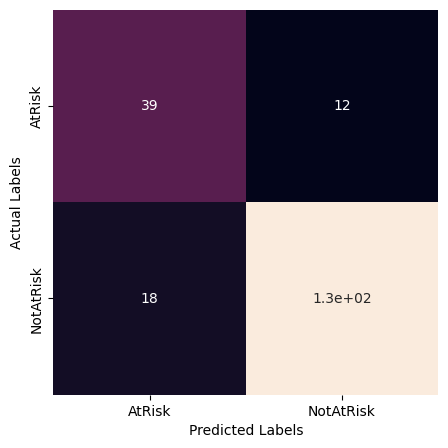

In [33]:
from imblearn.over_sampling import SMOTE

sd_XX = sd_X.copy()

pca = PCA(n_components=1)
sd_XX['media_usage_hours_pca'] = pca.fit_transform(sd_XX[['social_media_hours', 'netflix_hours']])
sd_XX.drop(columns=[
    'student_id', 'exam_score', 'grade'
], inplace=True)

X_train, X_test, y_train, y_test = train_test_split(
    sd_XX, sd_y, test_size=0.2, random_state=43
)

dt_binner = DecisionTreeDiscretiser(
    bin_output='boundaries',
    cv=5,
    precision=2,
    scoring='accuracy',
    regression=False,
    random_state=43,
    param_grid={'max_depth': [3, 5], 'ccp_alpha': [0.0, 0.01, 0.1]}
)

X_train_binned = dt_binner.fit_transform(X_train, y_train)
X_test_binned = dt_binner.transform(X_test)

X_train = pd.DataFrame(X_train_binned)
X_test = pd.DataFrame(X_test_binned)
y_train = pd.Series(y_train)

# Process categorical columns: impute + ordinal encode
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Pipeline for the preprocessing
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

# Fit the encoder on the binned training set
X_train = pd.DataFrame(preprocessor.fit_transform(X_train[cat_cols]), columns=cat_cols)
X_test  = pd.DataFrame(preprocessor.transform(X_test[cat_cols]), columns=cat_cols)


# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=43)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Train and evaluate the classifier
clf = DecisionTreeClassifier(random_state=43)
ad.cross_validation_avg_scores(X_train, y_train, clf, cv_=5, print_dict=False)
y_pred = clf.predict(X_test)
print(ad.classification_report(y_test, y_pred))
ad.plot_confusion_matrix(y_test, y_pred)

Mean Accuracy is 91.07 +/- 1.52
Mean Precision is 91.17 +/- 1.54
Mean Recall is 91.07 +/- 1.52
Mean F-score is 91.07 +/- 1.52
              precision    recall  f1-score   support

      AtRisk       0.69      0.80      0.75        51
   NotAtRisk       0.93      0.88      0.90       149

    accuracy                           0.86       200
   macro avg       0.81      0.84      0.82       200
weighted avg       0.87      0.86      0.86       200



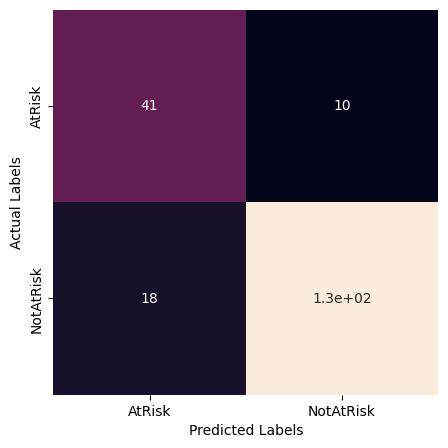

In [34]:
from imblearn.over_sampling import BorderlineSMOTE

sd_XX = sd_X.copy()
pca = PCA(n_components=1)
sd_XX['media_usage_hours_pca'] = pca.fit_transform(sd_XX[['social_media_hours', 'netflix_hours']])

sd_XX.drop(columns=[
    'student_id', 'exam_score', 'grade'
], inplace=True)

X_train, X_test, y_train, y_test = train_test_split(
    sd_XX, sd_y, test_size=0.2, random_state=43
)

dt_binner = DecisionTreeDiscretiser(
    bin_output='boundaries',
    cv=5,
    precision=2,
    scoring='accuracy',
    regression=False,
    random_state=43,
    param_grid={'max_depth': [3, 5], 'ccp_alpha': [0.0, 0.01, 0.1]}
)

X_train_binned = dt_binner.fit_transform(X_train, y_train)
X_test_binned = dt_binner.transform(X_test)

X_train = pd.DataFrame(X_train_binned)
X_test = pd.DataFrame(X_test_binned)
y_train = pd.Series(y_train)

# Process categorical columns: impute + ordinal encode
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

# Fit the encoder on the binned training set
X_train = pd.DataFrame(preprocessor.fit_transform(X_train[cat_cols]), columns=cat_cols)
X_test  = pd.DataFrame(preprocessor.transform(X_test[cat_cols]), columns=cat_cols)

# Apply BorderlineSMOTE( to handle class imbalance
smote = BorderlineSMOTE(random_state=43, k_neighbors=3, m_neighbors=3)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Train and evaluate the classifier
clf = DecisionTreeClassifier(random_state=43)
ad.cross_validation_avg_scores(X_train, y_train, clf, cv_=5, print_dict=False)
y_pred = clf.predict(X_test)
print(ad.classification_report(y_test, y_pred))
ad.plot_confusion_matrix(y_test, y_pred)

When comparing the two outcomes, the model using **SMOTE** with `class_weight='balanced'` achieved a solid performance, with an accuracy of 89.32% and a strong F1-score of 89.31%. However, the model using **BorderlineSMOTE** without `class_weight='balanced'` outperformed it, achieving an accuracy of 90.46% and a higher F1-score of 90.45%. The removal of `class_weight='balanced'` allowed **BorderlineSMOTE** to more effectively generate synthetic samples near the decision boundary, leading to better handling of class imbalance. This highlights that in cases of imbalanced data, using **BorderlineSMOTE** without the `class_weight='balanced'` setting can improve performance, as both techniques address imbalance in different ways, potentially leading to conflicting adjustments when used together.


Trying out a different classifier like **RandomForest** helped validate the robustness of our preprocessing pipeline. The results showed a noticeable boost in performance, with a higher mean accuracy and F1-score compared to the Decision Tree model. This suggests that ensemble methods like RandomForest can better capture the complex patterns in the data, especially when combined with techniques like PCA, binning, scaling, and BorderlineSMOTE for class balance.

It's time to start thinking about overfitting at this stage ....

In [35]:
clf.get_depth(), clf.get_n_leaves()

(11, 85)

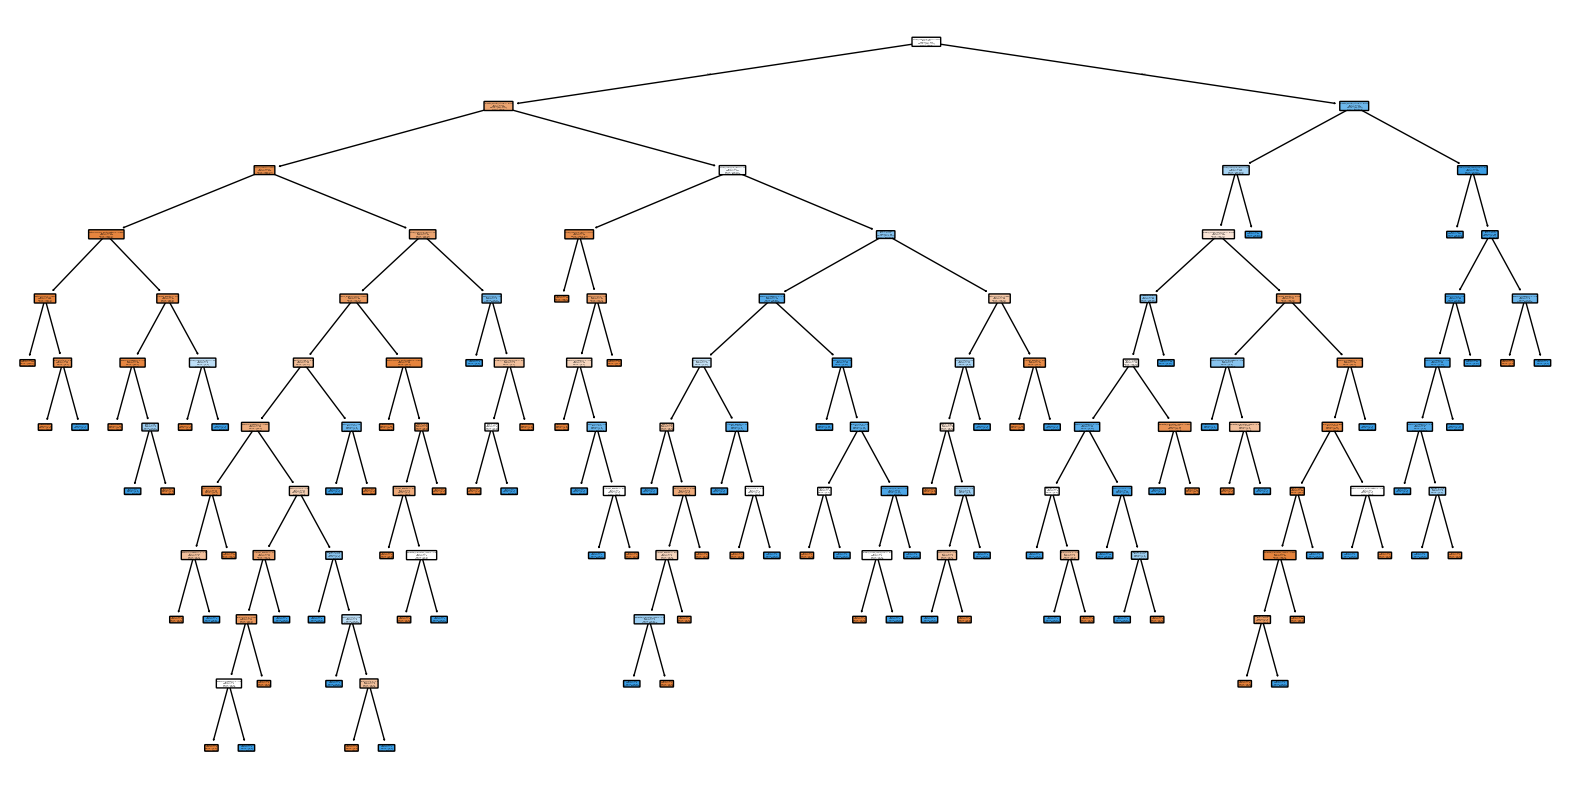

In [36]:
# Visualize the pruned decision tree
plt.figure(figsize=(20, 10))  # Adjust the size if necessary
plot_tree(
    clf, 
    filled=True, 
    feature_names=X_train.columns, 
    class_names=clf.classes_.astype(str),  # Ensure class names are in string format
    rounded=True
)
plt.show()

Apply a combination of pre/post pruning to avoid overfitting

Best parameters found: {'splitter': 'best', 'min_samples_split': 4, 'min_samples_leaf': 2, 'min_impurity_decrease': 0.03, 'max_depth': 9, 'criterion': 'entropy', 'ccp_alpha': 0.003}
Mean Accuracy is 88.09 +/- 2.98
Mean Precision is 88.30 +/- 3.01
Mean Recall is 88.09 +/- 2.97
Mean F-score is 88.08 +/- 2.98
              precision    recall  f1-score   support

      AtRisk       0.67      0.84      0.75        51
   NotAtRisk       0.94      0.86      0.90       149

    accuracy                           0.85       200
   macro avg       0.81      0.85      0.82       200
weighted avg       0.87      0.85      0.86       200



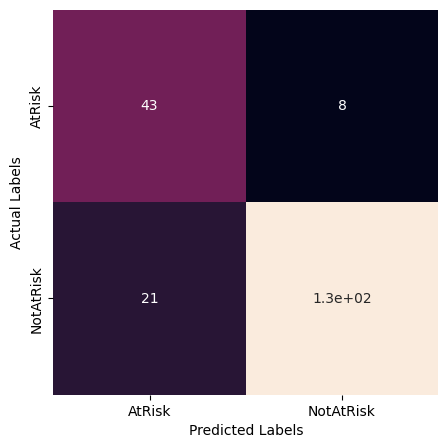

In [44]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

sd_XX = sd_X.copy()
pca = PCA(n_components=1)
sd_XX['media_usage_hours_pca'] = pca.fit_transform(sd_XX[['social_media_hours', 'netflix_hours']])

sd_XX.drop(columns=[
    'student_id', 'exam_score', 'grade'
], inplace=True)

X_train, X_test, y_train, y_test = train_test_split(
    sd_XX, sd_y, test_size=0.2, random_state=43
)

dt_binner = DecisionTreeDiscretiser(
    bin_output='boundaries',
    cv=5,
    precision=2,
    scoring='accuracy',
    regression=False,
    random_state=43,
    param_grid={'max_depth': [3, 5], 'ccp_alpha': [0.0, 0.01, 0.1]}
)

X_train_binned = dt_binner.fit_transform(X_train, y_train)
X_test_binned = dt_binner.transform(X_test)

X_train = pd.DataFrame(X_train_binned)
X_test = pd.DataFrame(X_test_binned)
y_train = pd.Series(y_train)

# Process categorical columns: impute + ordinal encode
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

# Fit the encoder on the binned training set
X_train = pd.DataFrame(preprocessor.fit_transform(X_train[cat_cols]), columns=cat_cols)
X_test  = pd.DataFrame(preprocessor.transform(X_test[cat_cols]), columns=cat_cols)

# Apply BorderlineSMOTE( to handle class imbalance
smote = BorderlineSMOTE(random_state=43, k_neighbors=3, m_neighbors=3)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Train and evaluate the classifier
# Define the parameter distribution for RandomizedSearchCV
params_dist = {
    'splitter': ['best', 'random'],
    'criterion' : ['gini', 'entropy'],
    'max_depth': range(3, 11),
    'min_impurity_decrease' : np.arange(0.01, 0.3, 0.01),
    'min_samples_leaf': range(2, 20, 4),
    'min_samples_split': range(2, 10, 2),
    'ccp_alpha': [0.003, 0.005, 0.007]
}
# Define the base DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=43)

# Perform RandomizedSearchCV to find the best hyperparameters
random_search = RandomizedSearchCV(
    clf,
    param_distributions=params_dist,
    n_iter=100,  # Number of random parameter combinations to try
    cv=5,  # 5-fold cross-validation
    random_state=43,
    n_jobs=-1,
    scoring='accuracy'
)

# Fit the randomized search to the training data
random_search.fit(X_train, y_train)

# Print best parameters and performance
print(f'Best parameters found: {random_search.best_params_}')

# Train and evaluate the classifier
best_clf = random_search.best_estimator_
ad.cross_validation_avg_scores(X_train, y_train, best_clf, cv_=5, print_dict=False)
y_pred = best_clf.predict(X_test)
print(ad.classification_report(y_test, y_pred))
ad.plot_confusion_matrix(y_test, y_pred)

In [45]:
best_clf.get_depth(), best_clf.get_n_leaves()

(4, 7)

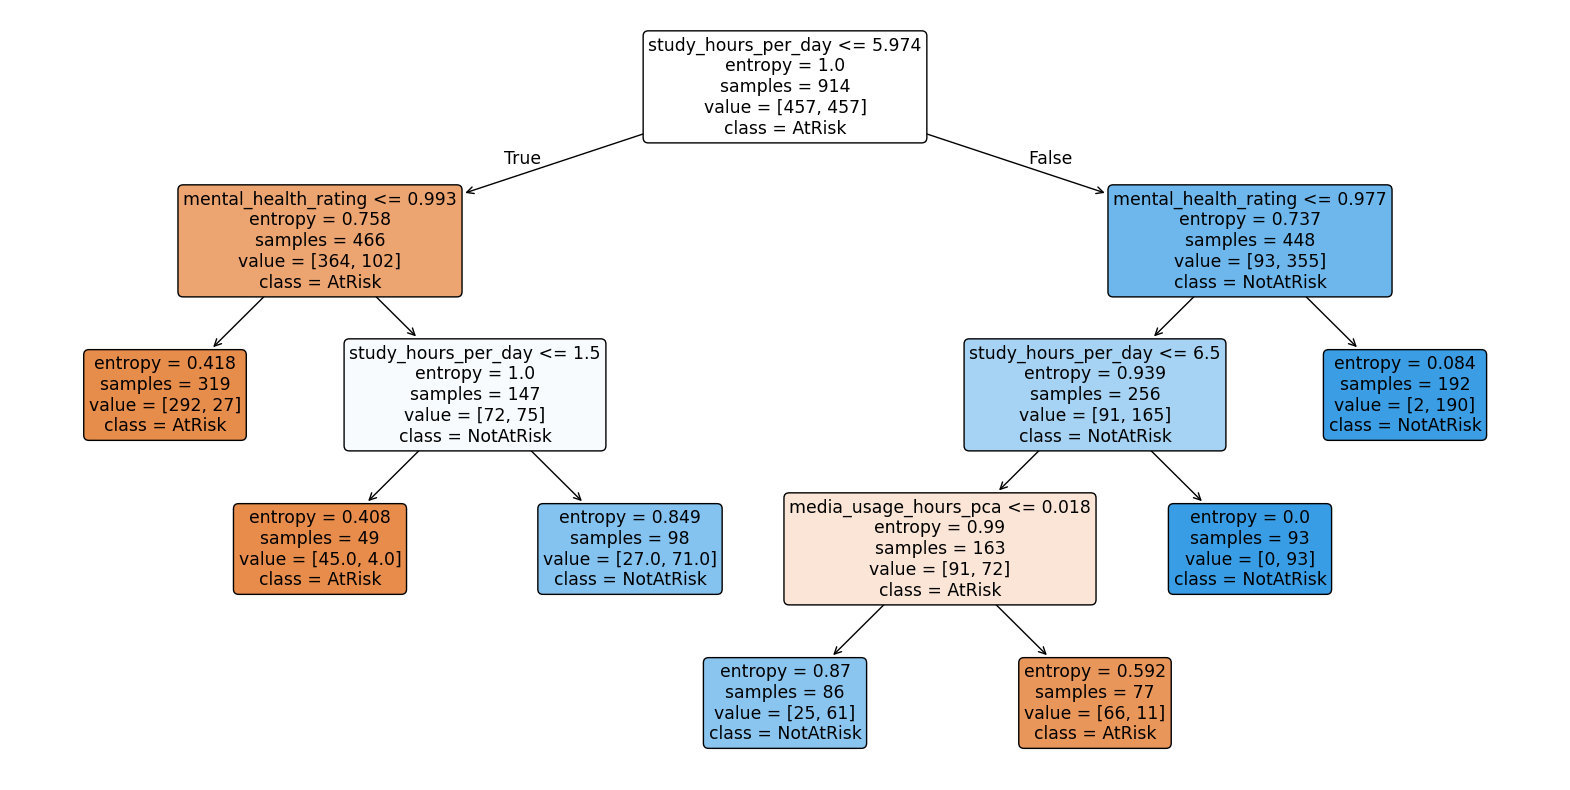

In [46]:
# Visualize the pruned decision tree
plt.figure(figsize=(20, 10))  # Adjust the size if necessary
plot_tree(
    best_clf, 
    filled=True, 
    feature_names=X_train.columns, 
    class_names=best_clf.classes_.astype(str),  # Ensure class names are in string format
    rounded=True
)
plt.show()

Performance is good but downgraded 

### **Weighting using embedded methods**

#### **Randomized search**

Best parameters found: {'splitter': 'best', 'min_samples_split': 8, 'min_samples_leaf': 2, 'min_impurity_decrease': 0.01, 'max_depth': 9, 'criterion': 'entropy', 'ccp_alpha': 0.007}
Mean Accuracy is 89.58 +/- 2.58
Mean Precision is 89.96 +/- 2.51
Mean Recall is 89.58 +/- 2.58
Mean F-score is 89.56 +/- 2.59
              precision    recall  f1-score   support

      AtRisk       0.66      0.88      0.76        51
   NotAtRisk       0.95      0.85      0.90       149

    accuracy                           0.85       200
   macro avg       0.81      0.86      0.83       200
weighted avg       0.88      0.85      0.86       200



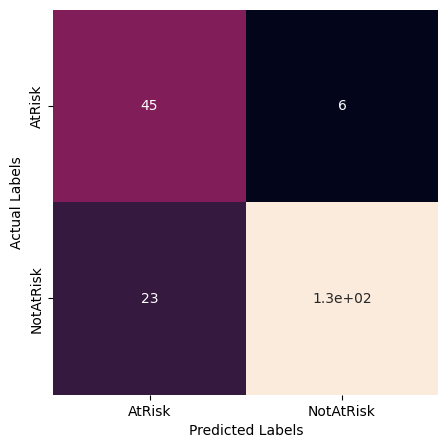

In [47]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

sd_XX = sd_X.copy()
pca = PCA(n_components=1)
sd_XX['media_usage_hours_pca'] = pca.fit_transform(sd_XX[['social_media_hours', 'netflix_hours']])

sd_XX.drop(columns=[
    'student_id', 'exam_score', 'grade'
], inplace=True)

X_train, X_test, y_train, y_test = train_test_split(
    sd_XX, sd_y, test_size=0.2, random_state=43
)

dt_binner = DecisionTreeDiscretiser(
    bin_output='boundaries',
    cv=5,
    precision=2,
    scoring='accuracy',
    regression=False,
    random_state=43,
    param_grid={'max_depth': [3, 5], 'ccp_alpha': [0.0, 0.01, 0.1]}
)

X_train_binned = dt_binner.fit_transform(X_train, y_train)
X_test_binned = dt_binner.transform(X_test)

X_train = pd.DataFrame(X_train_binned)
X_test = pd.DataFrame(X_test_binned)
y_train = pd.Series(y_train)

cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

# Fit the encoder on the binned training set
X_train = pd.DataFrame(preprocessor.fit_transform(X_train[cat_cols]), columns=cat_cols)
X_test  = pd.DataFrame(preprocessor.transform(X_test[cat_cols]), columns=cat_cols)

# Apply BorderlineSMOTE( to handle class imbalance
smote = BorderlineSMOTE(random_state=43, k_neighbors=3, m_neighbors=3)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Apply standard scaling
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=cat_cols)
X_test = pd.DataFrame(scaler.transform(X_test), columns=cat_cols)

# Define the Stratified K-Fold cross-validator
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=43)

# Train and evaluate the classifier
# Define the parameter distribution for RandomizedSearchCV
params_dist = {
    'splitter': ['best', 'random'],
    'criterion' : ['gini', 'entropy'],
    'max_depth': range(3, 11),
    'min_impurity_decrease' : np.arange(0.01, 0.3, 0.01),
    'min_samples_leaf': range(2, 20, 4),
    'min_samples_split': range(2, 10, 2),
    'ccp_alpha': [0.003, 0.005, 0.007]
}
# Define the base DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=43)

# Perform RandomizedSearchCV to find the best hyperparameters
random_search = RandomizedSearchCV(
    clf,
    param_distributions=params_dist,
    n_iter=100,  # Number of random parameter combinations to try
    cv=stratified_cv,
    random_state=43,
    n_jobs=-1,
    scoring='accuracy'
)

# Fit the randomized search to the training data
random_search.fit(X_train, y_train)

# Print best parameters and performance
print(f'Best parameters found: {random_search.best_params_}')

# Train and evaluate the classifier
best_clf = random_search.best_estimator_
ad.cross_validation_avg_scores(X_train, y_train, best_clf, cv_=5, print_dict=False)
y_pred = best_clf.predict(X_test)
print(ad.classification_report(y_test, y_pred))
ad.plot_confusion_matrix(y_test, y_pred)

['age', 'attendance_percentage', 'diet_quality', 'exercise_frequency', 'extracurricular_participation', 'gender', 'internet_quality', 'mental_health_rating', 'netflix_hours', 'parental_education_level', 'part_time_job', 'sleep_hours', 'social_media_hours', 'study_hours_per_day', 'media_usage_hours_pca'] 15
Best parameters found: {'ccp_alpha': 0.008462226447329869, 'criterion': 'entropy', 'max_depth': 9, 'min_impurity_decrease': 0.01, 'min_samples_leaf': 6, 'min_samples_split': 6, 'splitter': 'best'}
Mean Accuracy is 88.88 +/- 2.00
Mean Precision is 89.13 +/- 1.86
Mean Recall is 88.87 +/- 2.01
Mean F-score is 88.86 +/- 2.02
              precision    recall  f1-score   support

      AtRisk       0.64      0.86      0.73        51
   NotAtRisk       0.95      0.83      0.89       149

    accuracy                           0.84       200
   macro avg       0.79      0.85      0.81       200
weighted avg       0.87      0.84      0.85       200



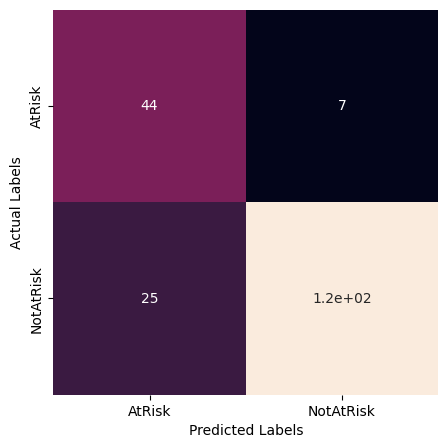

In [63]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier 

sd_XX = sd_X.copy()
pca = PCA(n_components=1)
sd_XX['media_usage_hours_pca'] = pca.fit_transform(sd_XX[['social_media_hours', 'netflix_hours']])

sd_XX.drop(columns=[
    'student_id', 'exam_score', 'grade'
], inplace=True)

X_train, X_test, y_train, y_test = train_test_split(
    sd_XX, sd_y, test_size=0.2, random_state=43
)

dt_binner = DecisionTreeDiscretiser(
    bin_output='boundaries',
    cv=5,
    precision=2,
    scoring='accuracy',
    regression=False,
    random_state=43,
    param_grid={'max_depth': [3, 5], 'ccp_alpha': [0.0, 0.01, 0.1]}
)

X_train_binned = dt_binner.fit_transform(X_train, y_train)
X_test_binned = dt_binner.transform(X_test)

X_train = pd.DataFrame(X_train_binned)
X_test = pd.DataFrame(X_test_binned)
y_train = pd.Series(y_train)

cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

# Fit the encoder on the binned training set
X_train = pd.DataFrame(preprocessor.fit_transform(X_train[cat_cols]), columns=cat_cols)
X_test  = pd.DataFrame(preprocessor.transform(X_test[cat_cols]), columns=cat_cols)

# Apply BorderlineSMOTE( to handle class imbalance
smote = BorderlineSMOTE(random_state=43, k_neighbors=3, m_neighbors=5)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Apply standard scaling
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=cat_cols)
X_test = pd.DataFrame(scaler.transform(X_test), columns=cat_cols)

# Embedded feature selection with SelectFromModel
selector_estimator = DecisionTreeClassifier(max_depth=8, min_samples_split=5, min_samples_leaf=18, ccp_alpha=0.007,random_state=43)
sfm = SelectFromModel(estimator=selector_estimator, threshold='median')
X_train_selected = sfm.fit_transform(X_train, y_train)
X_test_selected = sfm.transform(X_test)
selected_features = [cat_cols[index] for index in sfm.get_support(indices=True)]
print(selected_features, len(selected_features))
X_train = pd.DataFrame(X_train_selected, columns=selected_features)
X_test = pd.DataFrame(X_test_selected, columns=selected_features)

# Define the Stratified K-Fold cross-validator
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=43)

# Train and evaluate the classifier
# Define the parameter distribution for RandomizedSearchCV
params_dist = {
    'splitter': ['best', 'random'],
    'criterion' : ['gini', 'entropy'],
    'max_depth': range(3, 11),
    'min_impurity_decrease' : np.arange(0.01, 0.3, 0.01),
    'min_samples_leaf': range(2, 20, 4),
    'min_samples_split': range(2, 10, 2),
    'ccp_alpha': uniform(loc=0.005, scale=0.004)
}
# Define the base DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=43)

# Perform RandomizedSearchCV to find the best hyperparameters
random_search = RandomizedSearchCV(
    clf,
    param_distributions=params_dist,
    n_iter=500,  # Number of random parameter combinations to try
    cv=stratified_cv,
    random_state=43,
    n_jobs=-1,
    scoring='accuracy'
)

# Fit the randomized search to the training data
random_search.fit(X_train, y_train)

# Print best parameters and performance
print(f'Best parameters found: {random_search.best_params_}')

# Train and evaluate the classifier
best_clf = random_search.best_estimator_
ad.cross_validation_avg_scores(X_train, y_train, best_clf, cv_=5, print_dict=False)
y_pred = best_clf.predict(X_test)
print(ad.classification_report(y_test, y_pred))
ad.plot_confusion_matrix(y_test, y_pred)

In [64]:
best_clf.get_depth(), best_clf.get_n_leaves()

(6, 14)

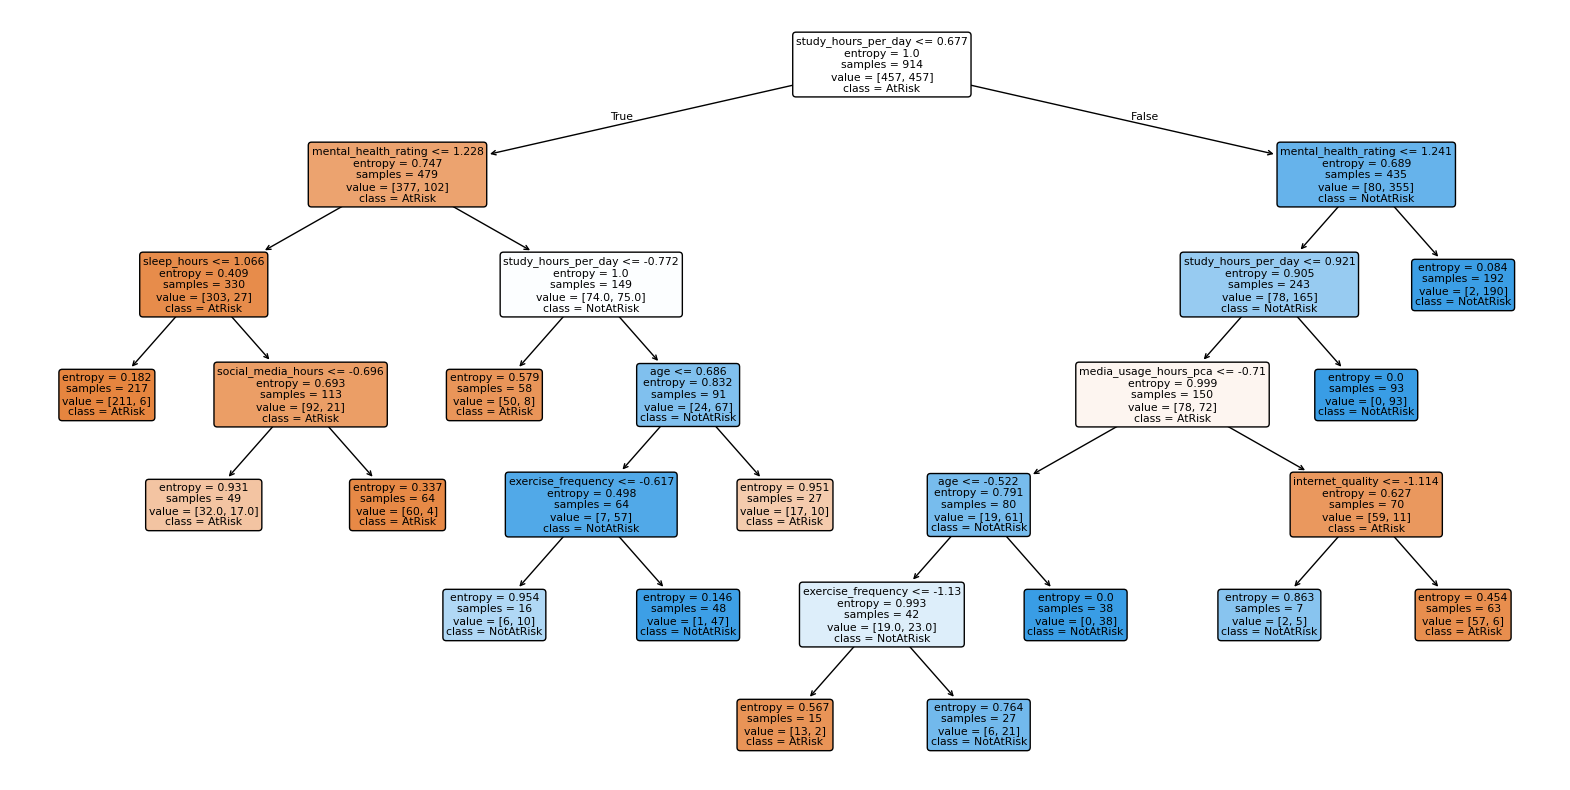

In [65]:
# Visualize the pruned decision tree
plt.figure(figsize=(20, 10))  # Adjust the size if necessary
plot_tree(
    best_clf, 
    filled=True, 
    feature_names=X_train.columns, 
    class_names=best_clf.classes_.astype(str),  # Ensure class names are in string format
    rounded=True
)
plt.show()

Best parameters found: {'ccp_alpha': 0.006731623306267057, 'criterion': 'entropy', 'max_depth': 6, 'min_impurity_decrease': 0.005, 'min_samples_leaf': 6, 'min_samples_split': 8, 'splitter': 'best'}
Mean Accuracy is 89.59 +/- 1.04
Mean Precision is 89.87 +/- 0.94
Mean Recall is 89.59 +/- 1.05
Mean F-score is 89.57 +/- 1.05
              precision    recall  f1-score   support

      AtRisk       0.75      0.84      0.79        56
   NotAtRisk       0.93      0.89      0.91       144

    accuracy                           0.88       200
   macro avg       0.84      0.86      0.85       200
weighted avg       0.88      0.88      0.88       200



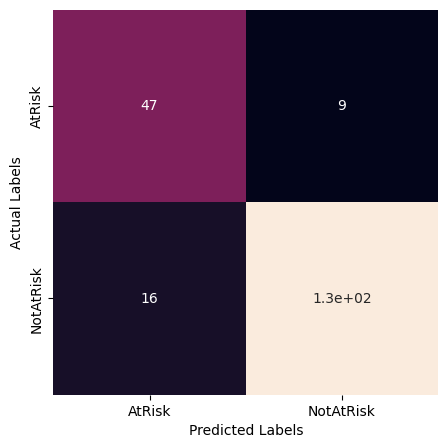

In [132]:
# Feature Engineering
sd_XX = sd_X.copy()
pca = PCA(n_components=1)
sd_XX['media_usage_hours_pca'] = pca.fit_transform(sd_XX[['social_media_hours', 'netflix_hours']])
sd_XX.drop(columns=['student_id', 'exam_score', 'grade'], inplace=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    sd_XX, sd_y, test_size=0.2, random_state=43, stratify=sd_y
)

# Better discretization settings: more robust grid
dt_binner = DecisionTreeDiscretiser(
    bin_output='boundaries',
    cv=5,
    precision=2,
    scoring='accuracy',
    regression=False,
    random_state=43,
    param_grid={'max_depth': [3, 4, 5, 6], 'ccp_alpha': [0.0, 0.005, 0.01]}
)

# Apply discretization
X_train_binned = dt_binner.fit_transform(X_train, y_train)
X_test_binned = dt_binner.transform(X_test)
X_train = pd.DataFrame(X_train_binned)
X_test = pd.DataFrame(X_test_binned)
y_train = pd.Series(y_train)

# Categorical encoding
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])
X_train = pd.DataFrame(preprocessor.fit_transform(X_train[cat_cols]), columns=cat_cols)
X_test  = pd.DataFrame(preprocessor.transform(X_test[cat_cols]), columns=cat_cols)

# BorderlineSMOTE with improved k_neighbors
smote = BorderlineSMOTE(random_state=43, k_neighbors=5, m_neighbors=10)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Scaling
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=cat_cols)
X_test = pd.DataFrame(scaler.transform(X_test), columns=cat_cols)

# Feature selection
selector_estimator = DecisionTreeClassifier(max_depth=7, min_samples_split=4,
                                            min_samples_leaf=10, ccp_alpha=0.007,
                                            random_state=43)
sfm = SelectFromModel(estimator=selector_estimator, threshold='median')
X_train_selected = sfm.fit_transform(X_train, y_train)
X_test_selected = sfm.transform(X_test)
selected_features = [cat_cols[index] for index in sfm.get_support(indices=True)]
X_train = pd.DataFrame(X_train_selected, columns=selected_features)
X_test = pd.DataFrame(X_test_selected, columns=selected_features)

# Cross-validation setup
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=43)

# Extended search space for better tuning
params_dist = {
    'splitter': ['best'],
    'criterion': ['gini', 'entropy'],
    'max_depth': range(5, 7),
    'min_impurity_decrease': np.linspace(0.005, 0.05, 10),
    'min_samples_leaf': range(4, 16, 2),
    'min_samples_split': range(4, 12, 2),
    'ccp_alpha': uniform(loc=0.005, scale=0.004)
}
clf = DecisionTreeClassifier(random_state=43)
random_search = RandomizedSearchCV(
    clf,
    param_distributions=params_dist,
    n_iter=300,
    cv=stratified_cv,
    random_state=43,
    n_jobs=-1,
    scoring='accuracy'
)
random_search.fit(X_train, y_train)

# Evaluate best classifier
print(f'Best parameters found: {random_search.best_params_}')
best_clf = random_search.best_estimator_

# Evaluation
ad.cross_validation_avg_scores(X_train, y_train, best_clf, cv_=5, print_dict=False)
y_pred = best_clf.predict(X_test)
print(ad.classification_report(y_test, y_pred))
ad.plot_confusion_matrix(y_test, y_pred)

In [127]:
best_clf.get_depth(), best_clf.get_n_leaves()

(6, 19)

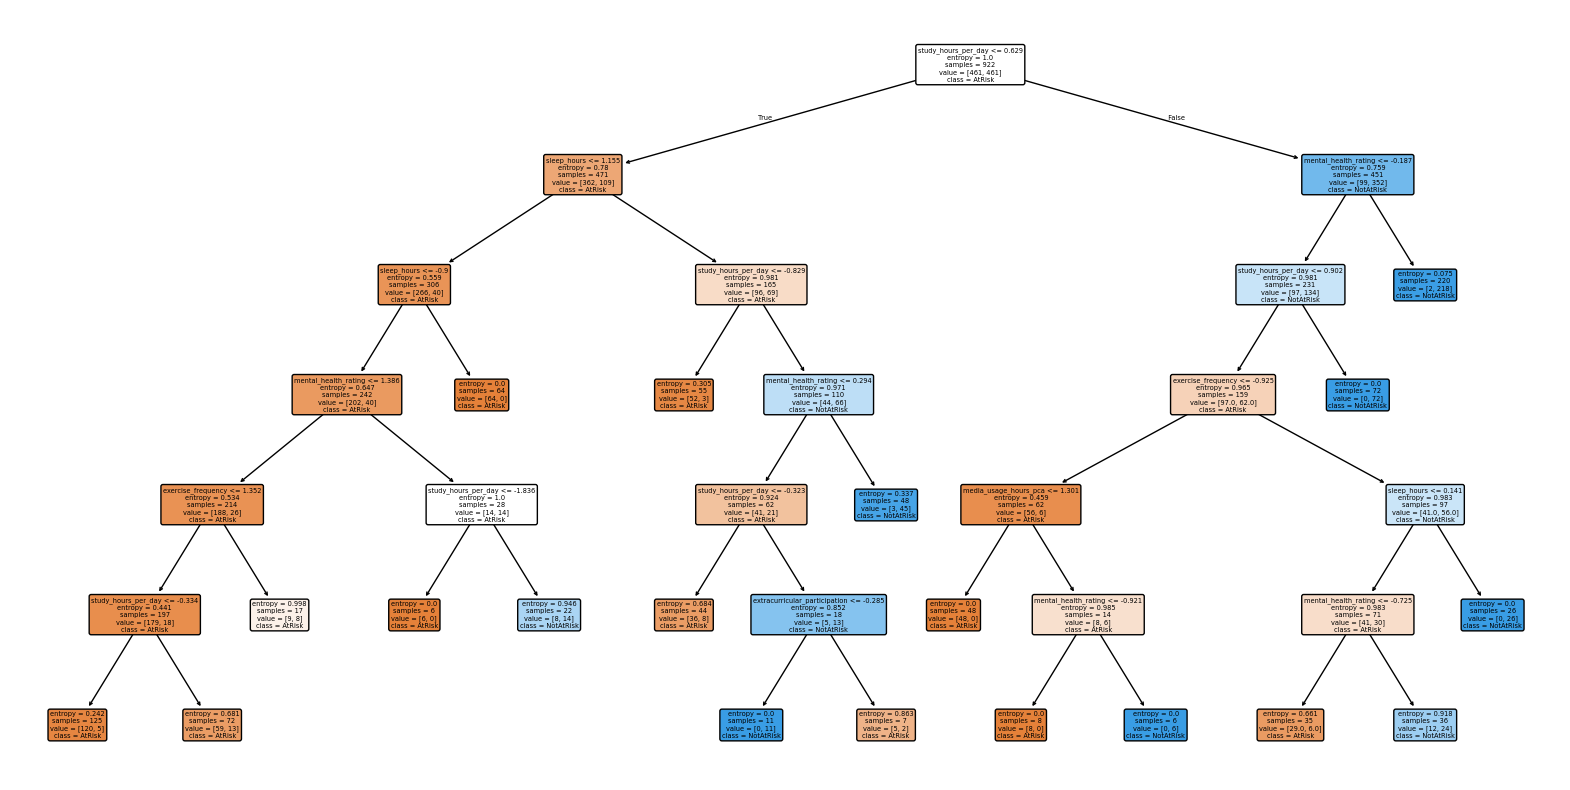

In [128]:
# Visualize the pruned decision tree
plt.figure(figsize=(20, 10))  # Adjust the size if necessary
plot_tree(
    best_clf, 
    filled=True, 
    feature_names=X_train.columns, 
    class_names=best_clf.classes_.astype(str),  # Ensure class names are in string format
    rounded=True
)
plt.show()